In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import mean_squared_error
import warnings


In [2]:
def add_specific_quantiles(group, quantiles):
    group['Quantile'] = pd.qcut(group['Observed'], quantiles, labels=False)
    return group

def nrmse(observed, modelled):
    mse = np.mean((observed - modelled) ** 2)
    rmse_value = np.sqrt(mse)
    normalized_rmse = rmse_value / np.mean(observed)  # Normalize by mean
    return normalized_rmse


In [3]:
dat = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Precip Filtered Cleaned Paired Modeled Observed Timeseries FINAL.csv')
dat

,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error,year,Error_bin,Error_bin_simple,Month
0,357421,MT97,454.0,2008-10-08,2008-10-16,45.69200,246.25,-113.968000,21.718927,38.35400,Precipitation_mm,76.592515,76.592515,2008,"(75, 100]",3,10
1,337506,MS10,395.0,2007-07-25,2007-08-01,32.30690,270.00,-90.318600,23.683537,8.44400,Precipitation_mm,64.346542,64.346542,2007,"(50, 75]",2,8
2,337510,MS10,399.0,2007-08-22,2007-08-29,32.30690,270.00,-90.318600,20.926037,7.62000,Precipitation_mm,63.586035,63.586035,2007,"(50, 75]",2,8
3,337514,MS10,400.0,2007-08-29,2007-09-05,32.30690,270.00,-90.318600,30.731049,12.70000,Precipitation_mm,58.673717,58.673717,2007,"(50, 75]",2,9
4,337518,MS10,401.0,2007-09-05,2007-09-12,32.30690,270.00,-90.318600,15.338802,14.22400,Precipitation_mm,7.267854,7.267854,2007,"(0, 25]",0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625287,709633,OR10,131.0,2007-04-18,2007-04-23,44.26664,237.50,-122.177000,2.049685,20.17268,WetDep_DOC_mgm2,884.184224,20.753170,2007,"(0, 25]",0,4
625288,709645,OR10,144.0,2007-07-18,2007-07-23,44.26664,237.50,-122.177000,4.770262,11.17600,WetDep_DOC_mgm2,134.284832,34.961172,2007,"(25, 50]",1,7
625289,709651,OR10,155.0,2007-10-03,2007-10-09,44.26664,237.50,-122.177000,4.802452,29.38780,WetDep_DOC_mgm2,511.933201,277.859467,2007,"(275, 300]",11,10
625290,709655,OR10,157.0,2007-10-16,2007-10-23,44.26664,237.50,-122.177000,10.268088,33.01492,WetDep_DOC_mgm2,221.529376,69.261900,2007,"(50, 75]",2,10


In [4]:
#Calculate percentiles of observed data for each variable 

# Apply the function to calculate specific quantiles for each group
specific_quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
dat = dat.groupby(['Variable']).apply(add_specific_quantiles, quantiles=specific_quantiles)

dat.reset_index(drop=True, inplace=True)


In [5]:
for i in dat.Variable.unique():
    for j in dat.Quantile.unique():
        # Subset data for the current variable and quantile
        quan_dat = dat.loc[((dat.Variable == i) & (dat.Quantile == j)), ]
        
        # Calculate NRMSE
        nrmse_value = nrmse(quan_dat['Observed'], quan_dat['Modelled'])
        dat.loc[(dat.Variable == i) & (dat.Quantile == j), 'NRMSE'] = nrmse_value
        
        # Calculate tolerance as a fraction of the standard deviation of observed values
        std_dev = quan_dat['Observed'].std()
        tolerance = 2 * std_dev  # Example: 10% of the standard deviation
        
        # Determine if the model is generally greater, less, or equal to observed
        mean_difference = quan_dat['Modelled'].mean() - quan_dat['Observed'].mean()
        
        if abs(mean_difference) <= tolerance:
            dat.loc[(dat.Variable == i) & (dat.Quantile == j), 'Model_vs_Observed'] = 'Equal'
        elif mean_difference > 0:
            dat.loc[(dat.Variable == i) & (dat.Quantile == j), 'Model_vs_Observed'] = 'Greater'
        else:
            dat.loc[(dat.Variable == i) & (dat.Quantile == j), 'Model_vs_Observed'] = 'Less'

# Extract the relevant columns
dat_quan = dat[['Variable', 'Quantile', 'NRMSE', 'Model_vs_Observed']].drop_duplicates().dropna()
dat_quan.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Quantile NRMSE data.csv')
dat_quan


,Variable,Quantile,NRMSE,Model_vs_Observed
0,Precipitation_mm,8.0,0.500727,Equal
1,Precipitation_mm,3.0,1.314178,Greater
2,Precipitation_mm,2.0,1.937514,Greater
3,Precipitation_mm,4.0,0.982863,Greater
6,Precipitation_mm,6.0,0.658422,Equal
8,Precipitation_mm,1.0,3.357202,Greater
9,Precipitation_mm,7.0,0.558705,Equal
10,Precipitation_mm,5.0,0.807518,Greater
17,Precipitation_mm,9.0,0.481909,Less
53,Precipitation_mm,0.0,6.863718,Greater


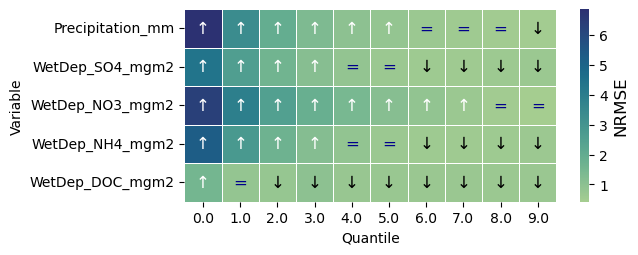

In [6]:
# Pivot the data for the heatmap
dat_quan_wide = dat_quan.pivot(index='Variable', columns='Quantile', values='NRMSE')

# Reorder the DataFrame rows
new_order = ['Precipitation_mm', "WetDep_SO4_mgm2",  "WetDep_NO3_mgm2", "WetDep_NH4_mgm2", "WetDep_DOC_mgm2"]
dat_quan_wide = dat_quan_wide.reindex(new_order)

# Create a similar pivot table for the arrows
arrow_data = dat_quan.pivot(index='Variable', columns='Quantile', values='Model_vs_Observed')
arrow_data = arrow_data.reindex(new_order)

# Map the arrows to the Model_vs_Observed data
arrow_mapping = {'Greater': '↑', 'Less': '↓', 'Equal' : '='}
arrow_annotations = arrow_data.replace(arrow_mapping)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 2.5))
heatmap = sns.heatmap(
    dat_quan_wide,
    annot=False,  # Turn off automatic annotations
    linewidth=0.5,
    cmap="crest",
    ax=ax,
    cbar_kws={"ticks": range(1, 11)}  # Specify ticks directly
)

# Modify the colorbar to show ticks from 1 to 10
colorbar = heatmap.collections[0].colorbar
colorbar.set_ticks(range(1, 7))  # Set tick positions
colorbar.set_ticklabels(range(1, 7))  # Set tick labels
colorbar.set_label("NRMSE", fontsize=12)  # Add label to the colorbar

# Loop over rows and columns to add arrows with color differentiation
for i in range(arrow_annotations.shape[0]):  # Loop over rows
    for j in range(arrow_annotations.shape[1]):  # Loop over columns
        arrow = arrow_annotations.iloc[i, j]
        
        # Set color based on arrow direction or "=" case
        if arrow == "↑":
            color = "white"
        elif arrow == "↓":
            color = "black"
        elif arrow == "=":
            color = "darkblue"  # Choose a distinct color for "=" (Equal)

        # Add the arrow annotation with the determined color
        ax.text(j + 0.5, i + 0.5, arrow, ha='center', va='center', 
                color=color, fontsize=12)

# Save and display the figure
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Heatmap_NRMSE_arrows.jpg', format='jpg', dpi=300)
plt.show()